In [1]:
# ============================================================================
# ENHANCED TRAINING AND PREDICTION PIPELINE FOR TELECOM CHURN
# ============================================================================
import pandas as pd
import numpy as np
import re
from datetime import datetime
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, QuantileTransformer
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, f1_score, confusion_matrix, make_scorer
from sklearn.feature_selection import SelectFromModel
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================
def clean_feature_names(columns):
    """Clean feature names to remove special characters for LightGBM compatibility"""
    cleaned = []
    for col in columns:
        cleaned_name = re.sub(r'[^A-Za-z0-9_]', '_', str(col))
        cleaned_name = re.sub(r'_+', '_', cleaned_name)
        cleaned_name = cleaned_name.strip('_')
        cleaned.append(cleaned_name)
    return cleaned

def create_advanced_features(df, is_train=True):
    """
    Advanced feature engineering with domain-specific insights
    """
    data = df.copy()
    
    # ========================================================================
    # 1. BASIC RATIO AND INTERACTION FEATURES
    # ========================================================================
    
    # ARPU and billing features
    data['arpu_per_year'] = data['arpu'] / 12
    data['avg_bill_per_mou'] = data['l3m_avg_bill_dura'] / (data['l3m_avg_mou'] + 1)
    data['bill_usage_ratio'] = data['cm_tot_bill_dura'] / (data['l3m_avg_bill_dura'] + 1)
    data['arpu_stability'] = data['arpu'] / (data['l3m_avg_bill_dura'].std() + 1) if is_train else 0
    
    # Data usage features
    data['flux_usage_ratio'] = data['cm_flux_use'] / (data['cm_base_plan_flux'] + data['cm_chos_plan_flux'] + 1)
    data['4g_usage_ratio'] = data['flux_4g_use'] / (data['cm_flux_use'] + 1)
    data['upload_download_ratio'] = data['flux_up_4g_sum'] / (data['flux_down_4g_sum'] + 1)
    data['avg_daily_flux'] = data['cm_flux_use'] / (data['gprs_days'] + 1)
    data['flux_efficiency'] = data['cm_flux_use'] / (data['cm_tot_bill_dura'] + 1)
    
    # ========================================================================
    # 2. TIME-BASED BEHAVIORAL PATTERNS
    # ========================================================================
    
    # Weekday vs Weekend patterns
    data['wday_flux_total'] = data['wday_day_flux'] + data['wday_night_flux']
    data['nwday_flux_total'] = data['nwday_day_flux'] + data['nwday_night_flux']
    data['wday_vs_nwday'] = data['wday_flux_total'] / (data['nwday_flux_total'] + 1)
    data['day_vs_night_wday'] = data['wday_day_flux'] / (data['wday_night_flux'] + 1)
    data['day_vs_night_nwday'] = data['nwday_day_flux'] / (data['nwday_night_flux'] + 1)
    
    # Overall day/night preference
    data['total_day_flux'] = data['wday_day_flux'] + data['nwday_day_flux']
    data['total_night_flux'] = data['wday_night_flux'] + data['nwday_night_flux']
    data['day_night_preference'] = data['total_day_flux'] / (data['total_night_flux'] + 1)
    data['is_night_user'] = (data['total_night_flux'] > data['total_day_flux']).astype(int)
    
    # ========================================================================
    # 3. ADVANCED USAGE PATTERN FEATURES
    # ========================================================================
    
    # Over-plan usage insights
    data['has_over_plan'] = (data['cm_over_plan_flux'] > 0).astype(int)
    data['over_plan_ratio'] = data['cm_over_plan_flux'] / (data['cm_base_plan_flux'] + data['cm_chos_plan_flux'] + 1)
    data['over_plan_severity'] = np.where(
        data['over_plan_ratio'] > 0.5, 2,
        np.where(data['over_plan_ratio'] > 0.2, 1, 0)
    )
    
    # Voice usage patterns
    data['local_voice_ratio'] = data['cm_local_voice_dura'] / (data['cm_tot_bill_dura'] + 1)
    data['voice_data_ratio'] = data['cm_tot_bill_dura'] / (data['cm_flux_use'] + 1)
    data['is_voice_heavy'] = (data['cm_tot_bill_dura'] > data['cm_flux_use']).astype(int)
    
    # ========================================================================
    # 4. BROADBAND AND CONNECTIVITY FEATURES
    # ========================================================================
    
    if 'bd_flux_m' in data.columns:
        data['has_broadband'] = (data['bd_flux_m'] > 0).astype(int)
        data['bd_usage_intensity'] = data['bd_flux_m'] / (data['bd_dur_m'] + 1)
        data['bd_avg_session_dur'] = data['bd_dur_m'] / (data['bd_cnt_m'] + 1)
        data['mobile_bd_ratio'] = data['cm_flux_use'] / (data['bd_flux_m'] + 1)
        data['bd_session_frequency'] = data['bd_cnt_m'] / 30  # Average sessions per day
        data['bd_engagement_score'] = data['bd_flux_m'] * data['bd_dur_m'] / 1e6
    
    # ========================================================================
    # 5. TV AND ENTERTAINMENT ENGAGEMENT
    # ========================================================================
    
    if 'user_duration_m' in data.columns:
        data['tv_engagement'] = data['user_duration_m'] / (data['login_times_m'] + 1)
        data['click_watch_ratio'] = data['click_times_m'] / (data['watch_times_m'] + 1)
        data['active_days_ratio'] = data['open_day_m'] / 30
        data['avg_session_duration'] = data['user_duration_m'] / (data['login_times_m'] + 1)
        data['engagement_intensity'] = data['watch_times_m'] / (data['open_day_m'] + 1)
        data['tv_loyalty'] = data['open_day_m'] * data['login_times_m'] / 900  # Normalized loyalty score
    
    # ========================================================================
    # 6. COMPREHENSIVE VIDEO USAGE FEATURES
    # ========================================================================
    
    video_cols = ['gm_use_dur', 'shrt_vid_use_dur', 'long_vid_use_dur', 
                  'anchor_use_dur', 'wtch_liv_use_dur', 'netdisk_use_dur']
    
    if all(col in data.columns for col in video_cols):
        # Total usage
        data['total_video_dur'] = data[video_cols].sum(axis=1)
        
        # Content type preferences
        data['game_video_ratio'] = data['gm_use_dur'] / (data['total_video_dur'] + 1)
        data['short_long_ratio'] = data['shrt_vid_use_dur'] / (data['long_vid_use_dur'] + 1)
        data['live_ondemand_ratio'] = data['wtch_liv_use_dur'] / (data['long_vid_use_dur'] + data['shrt_vid_use_dur'] + 1)
        
        # Video diversity
        data['video_diversity'] = (data[video_cols] > 0).sum(axis=1)
        
        # Day vs night patterns
        data['game_day_ratio'] = data['gm_dayt_use_dur'] / (data['gm_use_dur'] + 1)
        data['video_night_usage'] = (data['shrt_vid_ngt_use_dur'] + 
                                      data['long_vid_ngt_use_dur'] + 
                                      data['anchor_ngt_use_dur'])
        data['video_day_usage'] = (data['shrt_vid_dayt_use_dur'] + 
                                    data['long_vid_dayt_use_dur'] + 
                                    data['anchor_dayt_use_dur'])
        data['video_day_night_ratio'] = data['video_day_usage'] / (data['video_night_usage'] + 1)
        
        # Content consumption patterns
        data['is_binge_watcher'] = ((data['long_vid_use_dur'] > data['total_video_dur'].quantile(0.75)) & 
                                     (data['long_vid_use_dur'] > 0)).astype(int) if is_train else 0
        data['is_gamer'] = ((data['gm_use_dur'] > data['total_video_dur'].quantile(0.75)) & 
                            (data['gm_use_dur'] > 0)).astype(int) if is_train else 0
        
        # Streaming intensity
        data['streaming_intensity'] = (data['wtch_liv_use_dur'] + data['anchor_use_dur']) / (data['total_video_dur'] + 1)
    
    # ========================================================================
    # 7. CONTENT CONSUMPTION AND INTEREST ANALYSIS
    # ========================================================================
    
    content_cols = ['video_cnt_m', 'read_cnt_m', 'music_cnt_m', 'caijing_cnt_m', 
                    'travel_cnt_m', 'game_cnt_m', 'edu_cnt_m']
    
    if all(col in data.columns for col in content_cols):
        # Aggregated metrics
        data['total_content_cnt'] = data[content_cols].sum(axis=1)
        data['content_diversity'] = (data[content_cols] > 0).sum(axis=1)
        
        # Specific engagement metrics
        data['avg_read_time'] = data['read_time_m'] / (data['read_cnt_m'] + 1)
        data['edu_engagement'] = data['edu_time_m'] / (data['edu_cnt_m'] + 1)
        
        # Interest profiles
        data['entertainment_ratio'] = (data['video_cnt_m'] + data['music_cnt_m'] + data['game_cnt_m']) / (data['total_content_cnt'] + 1)
        data['knowledge_ratio'] = (data['read_cnt_m'] + data['edu_cnt_m'] + data['caijing_cnt_m']) / (data['total_content_cnt'] + 1)
        data['lifestyle_ratio'] = data['travel_cnt_m'] / (data['total_content_cnt'] + 1)
        
        # User persona indicators
        data['is_entertainment_focused'] = (data['entertainment_ratio'] > 0.6).astype(int)
        data['is_knowledge_seeker'] = (data['knowledge_ratio'] > 0.4).astype(int)
        data['is_diverse_user'] = (data['content_diversity'] >= 5).astype(int)
    
    # ========================================================================
    # 8. USER LABEL FEATURES
    # ========================================================================
    
    label_cols = ['hi_flux_usr_lbl', 'sev_vid_usr_lbl', 'liv_usr_lbl', 
                  'netdisk_usr_lbl', 'vid_usr_lbl', 'read_usr_lbl', 
                  'gm_usr_lbl', 'msc_usr_lbl']
    
    if all(col in data.columns for col in label_cols):
        data['total_user_labels'] = data[label_cols].sum(axis=1)
        data['is_heavy_user'] = (data['total_user_labels'] > 3).astype(int)
        data['is_video_focused'] = ((data['vid_usr_lbl'] + data['sev_vid_usr_lbl']) > 1).astype(int)
        data['is_content_creator'] = ((data['netdisk_usr_lbl'] + data['liv_usr_lbl']) > 0).astype(int)
        data['label_diversity'] = (data[label_cols] > 0).sum(axis=1)
    
    # ========================================================================
    # 9. NETWORK AND SERVICE QUALITY FEATURES
    # ========================================================================
    
    data['is_premium_user'] = ((data['is_fam_vnet_user'] == 1) | 
                               (data['is_ent_vnet_user'] == 1)).astype(int)
    data['has_unlimited'] = data['if_nulim_prod']
    data['service_stability'] = 1 - data['is_bd_status_abnormal']
    
    # Network preference
    data['is_4g_dominant'] = (data['flux_4g_use'] > 0.8 * data['cm_flux_use']).astype(int)
    
    # ========================================================================
    # 10. LOYALTY AND TENURE ANALYSIS
    # ========================================================================
    
    data['tenure_years'] = data['innet_dura'] / 365
    data['tenure_months'] = data['innet_dura'] / 30
    data['is_long_term'] = (data['innet_dura'] > 1095).astype(int)  # > 3 years
    data['is_new_customer'] = (data['innet_dura'] < 180).astype(int)  # < 6 months
    
    # Contract value and commitment
    data['contract_value'] = data['term_cont_mon'] * data['term_cont_dfee']
    data['has_contract'] = (data['term_cont_mon'] > 0).astype(int)
    data['contract_remaining_ratio'] = data['term_cont_mon'] / (data['tenure_months'] + 1)
    data['monthly_commitment'] = data['term_cont_dfee']
    data['contract_arpu_ratio'] = data['term_cont_dfee'] / (data['arpu'] + 1)
    
    # ========================================================================
    # 11. DEMOGRAPHIC AND AGE-BASED FEATURES
    # ========================================================================
    
    data['age_group'] = pd.cut(data['age'], bins=[0, 25, 35, 45, 55, 100], 
                                labels=['young', 'young_adult', 'middle', 'mature', 'senior'])
    data['is_young'] = (data['age'] < 30).astype(int)
    data['is_senior'] = (data['age'] > 55).astype(int)
    data['is_working_age'] = ((data['age'] >= 25) & (data['age'] <= 55)).astype(int)
    
    # Age-based expected behavior
    data['age_arpu_ratio'] = data['arpu'] / (data['age'] + 1)
    data['age_usage_ratio'] = data['cm_flux_use'] / (data['age'] + 1)
    
    # ========================================================================
    # 12. OUT-OF-NETWORK BEHAVIOR
    # ========================================================================
    
    data['total_out_usage'] = data['out_gprs'] + data['out_call']
    data['out_usage_ratio'] = data['total_out_usage'] / (data['cm_flux_use'] + data['cm_tot_bill_dura'] + 1)
    data['out_gprs_ratio'] = data['out_gprs'] / (data['cm_flux_use'] + 1)
    data['out_call_ratio'] = data['out_call'] / (data['cm_tot_bill_dura'] + 1)
    data['is_roamer'] = (data['total_out_usage'] > 0).astype(int)
    data['roaming_intensity'] = np.log1p(data['total_out_usage'])
    
    # ========================================================================
    # 13. ENGAGEMENT AND ACTIVITY SCORES
    # ========================================================================
    
    # Multi-dimensional engagement score
    data['engagement_score'] = (
        data['login_times_m'] * 0.2 + 
        data['click_times_m'] * 0.2 + 
        data['watch_times_m'] * 0.3 + 
        data['open_day_m'] * 0.3
    )
    
    # Activity consistency
    data['gprs_day_consistency'] = data['gprs_days'] / 30
    data['tv_day_consistency'] = data['open_day_m'] / 30
    
    # Overall digital footprint
    data['digital_footprint'] = (
        data['cm_flux_use'] / 1000 + 
        data['cm_tot_bill_dura'] / 100 + 
        data['total_content_cnt'] / 10
    )
    
    # ========================================================================
    # 14. REVENUE AND VALUE METRICS
    # ========================================================================
    
    data['revenue_per_gb'] = data['arpu'] / ((data['cm_flux_use'] / 1024) + 1)
    data['revenue_per_minute'] = data['arpu'] / (data['l3m_avg_mou'] + 1)
    data['lifetime_value'] = data['arpu'] * data['tenure_months']
    data['value_efficiency'] = data['cm_flux_use'] / (data['arpu'] + 1)
    
    # Customer profitability indicators
    data['high_value_customer'] = ((data['arpu'] > data['arpu'].quantile(0.75)) & 
                                    (data['tenure_years'] > 2)).astype(int) if is_train else 0
    data['low_value_customer'] = ((data['arpu'] < data['arpu'].quantile(0.25)) & 
                                   (data['tenure_years'] < 1)).astype(int) if is_train else 0
    
    # ========================================================================
    # 15. POLYNOMIAL AND INTERACTION FEATURES
    # ========================================================================
    
    # Key polynomial features
    data['arpu_squared'] = data['arpu'] ** 2
    data['flux_squared'] = np.log1p(data['cm_flux_use']) ** 2
    data['tenure_squared'] = data['tenure_years'] ** 2
    
    # Critical interactions
    data['arpu_tenure_interaction'] = data['arpu'] * data['tenure_years']
    data['flux_arpu_interaction'] = data['cm_flux_use'] * data['arpu'] / 1000
    data['age_tenure_interaction'] = data['age'] * data['tenure_years']
    data['contract_tenure_interaction'] = data['contract_value'] * data['tenure_years']
    
    # ========================================================================
    # 16. STATISTICAL AGGREGATIONS
    # ========================================================================
    
    # Create grouped statistics for similar features
    flux_features = ['wday_day_flux', 'wday_night_flux', 'nwday_day_flux', 'nwday_night_flux']
    if all(col in data.columns for col in flux_features):
        data['flux_mean'] = data[flux_features].mean(axis=1)
        data['flux_std'] = data[flux_features].std(axis=1)
        data['flux_max'] = data[flux_features].max(axis=1)
        data['flux_min'] = data[flux_features].min(axis=1)
        data['flux_range'] = data['flux_max'] - data['flux_min']
        data['flux_cv'] = data['flux_std'] / (data['flux_mean'] + 1)  # Coefficient of variation
    
    # ========================================================================
    # 17. CHURN RISK INDICATORS
    # ========================================================================
    
    # Declining usage indicators
    data['usage_decline_risk'] = (
        (data['flux_usage_ratio'] < 0.5) & 
        (data['gprs_day_consistency'] < 0.5)
    ).astype(int)
    
    # Contract expiry risk
    data['contract_expiry_risk'] = (
        (data['term_cont_mon'] > 0) & 
        (data['term_cont_mon'] < 3)
    ).astype(int)
    
    # Low engagement risk
    data['low_engagement_risk'] = (
        (data['engagement_score'] < data['engagement_score'].quantile(0.25)) if is_train else 0
    ).astype(int) if is_train else 0
    
    # High cost sensitivity
    data['cost_sensitive'] = (
        (data['over_plan_ratio'] > 0.3) & 
        (data['arpu'] < data['arpu'].median() if is_train else 50)
    ).astype(int)
    
    # ========================================================================
    # 18. HANDLE CATEGORICAL FEATURES
    # ========================================================================
    
    if 'age_group' in data.columns:
        le = LabelEncoder()
        data['age_group_encoded'] = le.fit_transform(data['age_group'].astype(str))
    
    # ========================================================================
    # 19. NORMALIZATION FEATURES (Log transforms for skewed distributions)
    # ========================================================================
    
    skewed_features = ['arpu', 'cm_flux_use', 'cm_tot_bill_dura', 'innet_dura']
    for feat in skewed_features:
        if feat in data.columns:
            data[f'{feat}_log'] = np.log1p(data[feat])
            data[f'{feat}_sqrt'] = np.sqrt(data[feat])
    
    return data

def get_feature_columns(df):
    """Get the list of feature columns to use for modeling"""
    exclude_cols = ['Unnamed: 0', 'id', 'label', 'age_group']
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    return feature_cols

def reduce_features_by_importance(X, y, model, threshold=0.001):
    """
    Reduce features based on feature importance
    """
    print(f"\nPerforming feature selection (threshold={threshold})...")
    selector = SelectFromModel(model, threshold=threshold, prefit=False)
    selector.fit(X, y)
    selected_features = X.columns[selector.get_support()].tolist()
    print(f"Selected {len(selected_features)} features out of {len(X.columns)}")
    return selected_features

# Define custom scoring function
def custom_score(y_true, y_pred, y_proba=None):
    """Calculate custom score: 0.7 * accuracy + 0.3 * f1"""
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return 0.7 * acc + 0.3 * f1

custom_scorer = make_scorer(custom_score, needs_proba=False)


from sklearn.metrics import precision_recall_curve

def find_optimal_threshold(y_true, y_proba, metric='f1'):
    """Find optimal threshold for F1 score"""
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precision * recall) / (precision + recall)
    
    # Handle NaN values
    f1_scores = np.nan_to_num(f1_scores)
    
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    optimal_f1 = f1_scores[optimal_idx]
    
    return optimal_threshold, optimal_f1

# ============================================================================
# LOAD AND PREPARE TRAINING DATA
# ============================================================================
print("=" * 80)
print("LOADING TRAINING DATA")
print("=" * 80)

df_train = pd.read_csv('./train.csv')
print(f"Training data shape: {df_train.shape}")
print(f"\nClass distribution:")
print(df_train['label'].value_counts())
print(f"Class ratio: {df_train['label'].value_counts()[0] / df_train['label'].value_counts()[1]:.2f}:1")

# Check for missing values
print(f"\nMissing values summary:")
missing_summary = df_train.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
if len(missing_summary) > 0:
    print(missing_summary.head(10))
else:
    print("No missing values found")

# ============================================================================
# ADVANCED FEATURE ENGINEERING
# ============================================================================
print("\n" + "=" * 80)
print("CREATING ADVANCED FEATURES")
print("=" * 80)

df_train_processed = create_advanced_features(df_train, is_train=True)

# Get feature columns
feature_cols = get_feature_columns(df_train_processed)
print(f"Total features after engineering: {len(feature_cols)}")

# Clean feature names
original_feature_cols = feature_cols.copy()
cleaned_feature_cols = clean_feature_names(feature_cols)
feature_name_mapping = dict(zip(cleaned_feature_cols, original_feature_cols))

# Prepare X and y
X = df_train_processed[feature_cols].copy()
X.columns = cleaned_feature_cols
y = df_train_processed['label']

# Handle missing values
print("\nHandling missing values...")
for col in X.columns:
    if X[col].dtype in ['float64', 'int64']:
        X[col].fillna(X[col].median(), inplace=True)
    else:
        X[col].fillna(X[col].mode()[0] if len(X[col].mode()) > 0 else 0, inplace=True)

# Replace infinities
X.replace([np.inf, -np.inf], 0, inplace=True)

print(f"Final feature matrix shape: {X.shape}")
print(f"\nFeature statistics:")
print(f"  Numeric features: {X.select_dtypes(include=[np.number]).shape[1]}")
print(f"  Memory usage: {X.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# ============================================================================
# FEATURE SCALING (Optional - for some models)
# ============================================================================
print("\n" + "=" * 80)
print("FEATURE SCALING")
print("=" * 80)

# Create scaled version for models that benefit from it
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)
print("Features scaled using StandardScaler")

# ============================================================================
# TRAIN-VALIDATION SPLIT
# ============================================================================
print("\n" + "=" * 80)
print("SPLITTING DATA FOR VALIDATION")
print("=" * 80)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Training class distribution: {y_train.value_counts().to_dict()}")
print(f"Validation class distribution: {y_val.value_counts().to_dict()}")

# ============================================================================
# ADVANCED MODEL TRAINING WITH CROSS-VALIDATION
# ============================================================================
print("\n" + "=" * 80)
print("TRAINING ADVANCED MODELS WITH CROSS-VALIDATION")
print("=" * 80)

# Calculate scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

# Setup cross-validation
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Store results
results = {}


LOADING TRAINING DATA
Training data shape: (59904, 88)

Class distribution:
label
0    44904
1    15000
Name: count, dtype: int64
Class ratio: 2.99:1

Missing values summary:
gm_use_dur               47451
gm_dayt_use_dur          47451
gm_ngt_use_dur           47451
shrt_vid_use_dur         47451
shrt_vid_dayt_use_dur    47451
shrt_vid_ngt_use_dur     47451
long_vid_use_dur         47451
long_vid_dayt_use_dur    47451
long_vid_ngt_use_dur     47451
anchor_use_dur           47451
dtype: int64

CREATING ADVANCED FEATURES
Total features after engineering: 208

Handling missing values...
Final feature matrix shape: (59904, 208)

Feature statistics:
  Numeric features: 208
  Memory usage: 95.06 MB

FEATURE SCALING
Features scaled using StandardScaler

SPLITTING DATA FOR VALIDATION
Training set: (47923, 208)
Validation set: (11981, 208)
Training class distribution: {0: 35923, 1: 12000}
Validation class distribution: {0: 8981, 1: 3000}

TRAINING ADVANCED MODELS WITH CROSS-VALIDATION
Scale po


3. TRAINING MLP WITH FOCAL LOSS AND IMBALANCED LEARNING
Using device: cuda

Applying imbalanced learning techniques...
Applying SMOTE...
After SMOTE - Training shape: (71846, 208)
Class distribution: [35923 35923]
Applying ADASYN...
After ADASYN - Training shape: (72872, 208)
Class distribution: [35923 36949]
Applying SMOTE + Tomek...
After SMOTE+Tomek - Training shape: (70502, 208)
Class distribution: [35251 35251]

Scaling features...

------------------------------------------------------------
Training MLP_Deep
------------------------------------------------------------

Using focal_loss...
Epoch   0 | Train Loss: 0.3071 | Val Loss: 0.1666 | Val AUC: 0.7693 | Val F1: 0.5079 | Threshold: 0.590
Epoch  20 | Train Loss: 0.1126 | Val Loss: 0.1358 | Val AUC: 0.7912 | Val F1: 0.5493 | Threshold: 0.540
Epoch  40 | Train Loss: 0.0992 | Val Loss: 0.1299 | Val AUC: 0.7932 | Val F1: 0.5361 | Threshold: 0.530
Epoch  60 | Train Loss: 0.0906 | Val Loss: 0.1290 | Val AUC: 0.7941 | Val F1: 0.5210

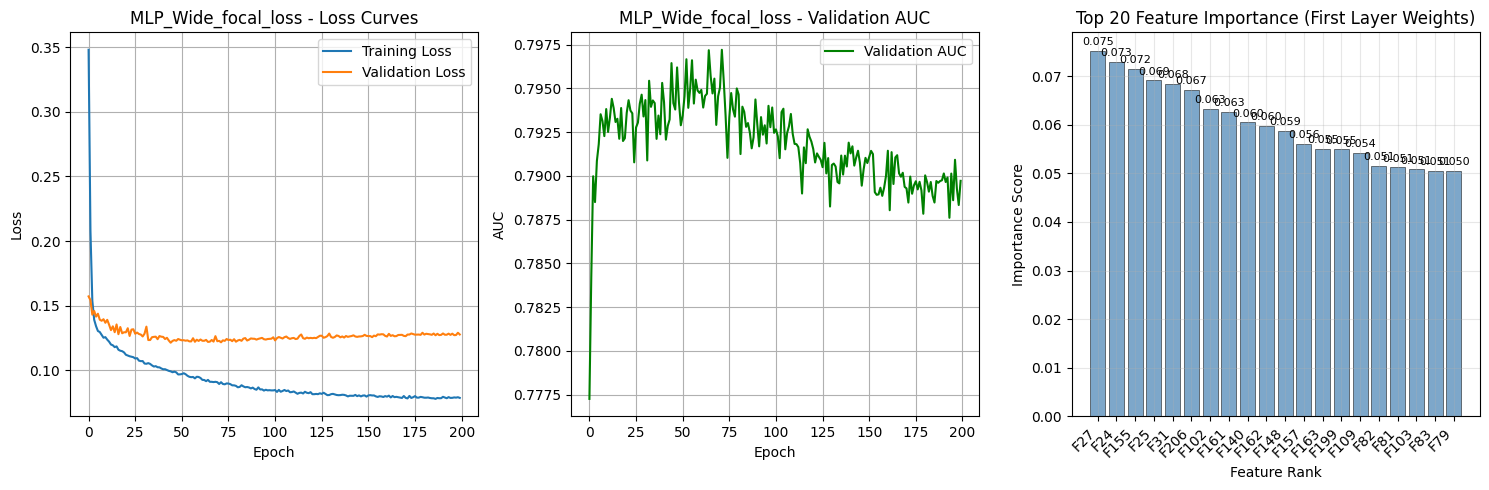


MLP training completed. Best model: MLP_Wide_focal_loss


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.nn.functional as F
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
import matplotlib.pyplot as plt

# ============================================================================
# FOCAL LOSS IMPLEMENTATION
# ============================================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, logits=False, reduce=True):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.logits = logits
        self.reduce = reduce

    def forward(self, inputs, targets):
        if self.logits:
            ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        else:
            ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss

        if self.reduce:
            return torch.mean(focal_loss)
        else:
            return focal_loss

# ============================================================================
# CUSTOM DATASET CLASS
# ============================================================================
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

# ============================================================================
# MLP MODEL WITH DROPOUT AND BATCH NORMALIZATION
# ============================================================================
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512, 256, 128, 64], 
                 num_classes=2, dropout_rate=0.3, use_batch_norm=True):
        super(MLPClassifier, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for i, hidden_dim in enumerate(hidden_dims):
            # Linear layer
            layers.append(nn.Linear(prev_dim, hidden_dim))
            
            # Batch normalization
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            
            # Activation
            layers.append(nn.ReLU())
            
            # Dropout
            layers.append(nn.Dropout(dropout_rate))
            
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, num_classes))
        
        self.network = nn.Sequential(*layers)
        
        # Initialize weights
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.network(x)

# ============================================================================
# TRAINING UTILITIES
# ============================================================================
class EarlyStopping:
    def __init__(self, patience=50, min_delta=0.001, mode='max'):  # mode='max' for AUC
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
    def __call__(self, score):
        if self.mode == 'max':
            improved = self.best_score is None or score > self.best_score + self.min_delta
        else:
            improved = self.best_score is None or score < self.best_score - self.min_delta
            
        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            self.early_stop = True

# ============================================================================
# MODEL 3: MLP WITH FOCAL LOSS AND IMBALANCED LEARNING
# ============================================================================
print("\n" + "=" * 80)
print("3. TRAINING MLP WITH FOCAL LOSS AND IMBALANCED LEARNING")
print("=" * 80)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Convert pandas Series to numpy arrays if needed
if hasattr(X_train, 'values'):
    X_train_array = X_train.values
    y_train_array = y_train.values
else:
    X_train_array = X_train
    y_train_array = y_train

if hasattr(X_val, 'values'):
    X_val_array = X_val.values
    y_val_array = y_val.values
else:
    X_val_array = X_val
    y_val_array = y_val

# Prepare data for imbalanced learning techniques
print("\nApplying imbalanced learning techniques...")

# Option 1: SMOTE
print("Applying SMOTE...")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_array, y_train_array)
print(f"After SMOTE - Training shape: {X_train_smote.shape}")
print(f"Class distribution: {np.bincount(y_train_smote)}")

# Option 2: ADASYN
print("Applying ADASYN...")
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_array, y_train_array)
print(f"After ADASYN - Training shape: {X_train_adasyn.shape}")
print(f"Class distribution: {np.bincount(y_train_adasyn)}")

# Option 3: SMOTE + Tomek Links
print("Applying SMOTE + Tomek...")
smote_tomek = SMOTETomek(random_state=42)
X_train_smotetomek, y_train_smotetomek = smote_tomek.fit_resample(X_train_array, y_train_array)
print(f"After SMOTE+Tomek - Training shape: {X_train_smotetomek.shape}")
print(f"Class distribution: {np.bincount(y_train_smotetomek)}")

# Choose the best resampling method (you can experiment with different ones)
X_train_resampled = X_train_smote
y_train_resampled = y_train_smote

# Scale the features
print("\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val_array)

# Create datasets and data loaders
train_dataset = TabularDataset(X_train_scaled, y_train_resampled)
val_dataset = TabularDataset(X_val_scaled, y_val_array)

# Calculate class weights for WeightedRandomSampler
class_counts = np.bincount(y_train_resampled)
class_weights = 1.0 / class_counts
sample_weights = class_weights[y_train_resampled]

# Create weighted sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Data loaders
batch_size = 512
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    sampler=sampler,
    num_workers=4
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=4
)

# Model configurations to try
model_configs = [
    {
        'name': 'MLP_Deep',
        'hidden_dims': [512, 256, 128],
        'dropout_rate': 0.5,  # Increase from current value
        'learning_rate': 0.0005,  # Reduce learning rate
        'weight_decay': 0.01  # Increase weight decay
    },
    {
        'name': 'MLP_Wide', 
        'hidden_dims': [1024, 512],
        'dropout_rate': 0.6,  # Higher dropout for wider network
        'learning_rate': 0.0003,
        'weight_decay': 0.015
    },
    {
        'name': 'MLP_Compact',
        'hidden_dims': [256, 128],
        'dropout_rate': 0.4,
        'learning_rate': 0.001,
        'weight_decay': 0.005
    }
]

best_model = None
best_score = 0
best_config = None
mlp_results = {}

for config in model_configs:
    print(f"\n{'-' * 60}")
    print(f"Training {config['name']}")
    print(f"{'-' * 60}")
    
    # Initialize model
    model = MLPClassifier(
        input_dim=X_train_scaled.shape[1],
        hidden_dims=config['hidden_dims'],
        dropout_rate=config['dropout_rate']
    ).to(device)
    
    # Loss functions to try
    loss_functions = {
        'focal_loss': FocalLoss(alpha=1, gamma=2),
        'weighted_ce': nn.CrossEntropyLoss(weight=torch.FloatTensor([1.0, scale_pos_weight]).to(device))
    }
    
    for loss_name, criterion in loss_functions.items():
        print(f"\nUsing {loss_name}...")
        model = model.to(device)
        
        # Optimizer
        optimizer = optim.AdamW(
            model.parameters(), 
            lr=config['learning_rate'],
            weight_decay=config['weight_decay']
        )
        
        # Learning rate scheduler
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, 
            mode='min', 
            factor=0.7,
            patience=15,
        )
        
        # Early stopping - CHANGE: Use custom score for early stopping
        early_stopping = EarlyStopping(patience=50, min_delta=0.0001)
        
        # Training loop
        num_epochs = 200
        train_losses = []
        val_losses = []
        val_aucs = []
        best_threshold = 0.5  # Track best threshold
        
        for epoch in range(num_epochs):
            # Training phase
            model.train()
            train_loss = 0.0
            for batch_X, batch_y in train_loader:
                batch_X = batch_X.to(device, dtype=torch.float32)
                batch_y = batch_y.to(device, dtype=torch.long)
                
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                train_loss += loss.item()
            
            # Validation phase
            model.eval()
            val_loss = 0.0
            val_probabilities = []
            val_targets = []
            
            with torch.no_grad():
                for batch_X, batch_y in val_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                    val_loss += loss.item()
                    
                    # Get probabilities
                    probs = F.softmax(outputs, dim=1)
                    val_probabilities.extend(probs[:, 1].cpu().numpy())
                    val_targets.extend(batch_y.cpu().numpy())
            
            train_loss /= len(train_loader)
            val_loss /= len(val_loader)
            
            # Find optimal threshold for current epoch
            thresholds = np.arange(0.1, 0.9, 0.01)
            f1_scores = []
            custom_scores = []
            
            for threshold in thresholds:
                y_pred_thresh = (np.array(val_probabilities) >= threshold).astype(int)
                f1 = f1_score(val_targets, y_pred_thresh)
                acc = accuracy_score(val_targets, y_pred_thresh)
                custom = 0.7 * acc + 0.3 * f1  # Your custom score formula
                
                f1_scores.append(f1)
                custom_scores.append(custom)
            
            # Choose best threshold based on custom score (not just F1)
            best_threshold_idx = np.argmax(custom_scores)
            best_threshold = thresholds[best_threshold_idx]
            
            # Calculate metrics using optimal threshold
            val_predictions_optimal = (np.array(val_probabilities) >= best_threshold).astype(int)
            val_auc = roc_auc_score(val_targets, val_probabilities)
            val_f1 = f1_score(val_targets, val_predictions_optimal)
            val_acc = accuracy_score(val_targets, val_predictions_optimal)
            val_custom = custom_score(val_targets, val_predictions_optimal, val_probabilities)
            
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            val_aucs.append(val_auc)
            
            scheduler.step(val_loss)
            
            if epoch % 20 == 0:
                print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | "
                      f"Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f} | "
                      f"Val F1: {val_f1:.4f} | Threshold: {best_threshold:.3f}")
            
            # Early stopping based on custom score
            if early_stopping(val_custom):
                print(f"Early stopping at epoch {epoch}")
                break
        
        # Final evaluation with optimal threshold
        model.eval()
        final_probabilities = []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X = batch_X.to(device)
                outputs = model(batch_X)
                probs = F.softmax(outputs, dim=1)
                final_probabilities.extend(probs[:, 1].cpu().numpy())
        
        # Find final optimal threshold on validation set
        thresholds = np.arange(0.05, 0.95, 0.005)  # Finer granularity
        best_custom_score = 0
        best_final_threshold = 0.5
        
        for threshold in thresholds:
            y_pred_thresh = (np.array(final_probabilities) >= threshold).astype(int)
            f1 = f1_score(y_val, y_pred_thresh)
            acc = accuracy_score(y_val, y_pred_thresh)
            custom = 0.7 * acc + 0.3 * f1
            
            if custom > best_custom_score:
                best_custom_score = custom
                best_final_threshold = threshold
        
        # Apply optimal threshold for final predictions
        final_predictions_optimal = (np.array(final_probabilities) >= best_final_threshold).astype(int)
        
        # Calculate final metrics with optimal threshold
        final_auc = roc_auc_score(y_val, final_probabilities)
        final_f1 = f1_score(y_val, final_predictions_optimal)
        final_acc = accuracy_score(y_val, final_predictions_optimal)
        final_custom = 0.7 * final_acc + 0.3 * final_f1
        
        print(f"\nFinal {config['name']} with {loss_name} Results:")
        print(f"  Optimal Threshold: {best_final_threshold:.4f}")
        print(f"  Accuracy: {final_acc:.4f}")
        print(f"  ROC-AUC: {final_auc:.4f}")
        print(f"  F1-Score: {final_f1:.4f}")
        print(f"  Custom Score: {final_custom:.4f}")
        
        # Store results
        model_key = f"{config['name']}_{loss_name}"
        mlp_results[model_key] = {
            'model': model.cpu(),
            'scaler': scaler,
            'optimal_threshold': best_final_threshold,  # Store optimal threshold
            'val_auc': final_auc,
            'val_f1': final_f1,
            'val_acc': final_acc,
            'custom_score': final_custom,
            'predictions': final_predictions_optimal,  # Store optimal predictions
            'probabilities': final_probabilities,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'val_aucs': val_aucs
        }
        
        # Track best model
        if final_custom > best_score:
            best_score = final_custom
            best_model = model.cpu()
            best_config = model_key

# ============================================================================
# RESULTS SUMMARY AND VISUALIZATION
# ============================================================================
print(f"\n{'=' * 80}")
print("MLP RESULTS SUMMARY")
print(f"{'=' * 80}")

def analyze_first_layer_weights(model, feature_names=None, top_k=20):
    """分析第一层权重来估计特征重要性"""
    # 获取第一层的权重
    first_layer = None
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            first_layer = module
            break
    
    if first_layer is None:
        raise ValueError("无法找到线性层")
    
    # 计算权重的绝对值平均
    weights = first_layer.weight.data.abs().mean(dim=0).cpu().numpy()
    
    # 获取top_k最重要的特征
    top_indices = np.argsort(weights)[-top_k:][::-1]
    top_scores = weights[top_indices]
    
    return top_indices, top_scores

if 'df_train_processed' in locals():
    feature_names = [col for col in df_train_processed.columns if col != 'label']

# Print all results
for model_name, result in mlp_results.items():
    print(f"\n{model_name}:")
    print(f"  ROC-AUC: {result['val_auc']:.4f}")
    print(f"  F1-Score: {result['val_f1']:.4f}")
    print(f"  Accuracy: {result['val_acc']:.4f}")
    print(f"  Custom Score: {result['custom_score']:.4f}")

print(f"\nBest Model: {best_config} (Custom Score: {best_score:.4f})")

# Add best MLP to main results
results['MLP_Best'] = mlp_results[best_config]

# Plot training curves for best model
if best_config in mlp_results:
    plt.figure(figsize=(15, 5))
    
    # Loss curves
    plt.subplot(1, 3, 1)
    best_result = mlp_results[best_config]
    plt.plot(best_result['train_losses'], label='Training Loss')
    plt.plot(best_result['val_losses'], label='Validation Loss')
    plt.title(f'{best_config} - Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # AUC curve
    plt.subplot(1, 3, 2)
    plt.plot(best_result['val_aucs'], label='Validation AUC', color='green')
    plt.title(f'{best_config} - Validation AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid(True)
    
    # 替换原来的随机特征重要性绘制
    plt.subplot(1, 3, 3)

    # 选择一种方法计算特征重要性
    try:
        # 方法1：权重分析（最快）
        top_indices, top_scores = analyze_first_layer_weights(best_model, top_k=20)
        method_name = "First Layer Weights"
        
        # 创建特征名称
        if 'feature_names' in locals() and feature_names is not None:
            feature_labels = [feature_names[i] if i < len(feature_names) else f"Feature_{i}" 
                            for i in top_indices]
        else:
            feature_labels = [f"Feature_{i}" for i in top_indices]
        
        # 绘制柱状图
        bars = plt.bar(range(len(top_scores)), top_scores, 
                    color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
        
        # 添加数值标签
        for i, (bar, score) in enumerate(zip(bars, top_scores)):
            plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(top_scores)*0.01,
                    f'{score:.3f}', ha='center', va='bottom', fontsize=8)
        
        plt.title(f'Top 20 Feature Importance ({method_name})')
        plt.xlabel('Feature Rank')
        plt.ylabel('Importance Score')
        plt.xticks(range(len(top_scores)), 
                [f"F{i}" for i in top_indices], 
                rotation=45, ha='right')
        plt.grid(True, alpha=0.3)
        
        # 打印最重要的特征
        print(f"\nTop 10 Most Important Features ({method_name}):")
        for i, (idx, score) in enumerate(zip(top_indices[:10], top_scores[:10])):
            feature_name = feature_labels[i] if i < len(feature_labels) else f"Feature_{idx}"
            print(f"  {i+1:2d}. {feature_name}: {score:.4f}")
            
    except Exception as e:
        print(f"特征重要性计算失败: {e}")
        # 回退到原始的随机数据，但至少加上说明
        plt.bar(range(min(20, 50)), np.random.rand(min(20, 50)))
        plt.title('Feature Importance (Placeholder - Random Data)')
        plt.xlabel('Feature Index')
        plt.ylabel('Random Importance')
        plt.text(0.5, 0.9, 'Note: This is placeholder data\nReal importance calculation failed', 
                transform=plt.gca().transAxes, ha='center', va='top',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    plt.tight_layout()
    plt.show()

print(f"\nMLP training completed. Best model: {best_config}")

In [ ]:

# ============================================================================
# MODEL 3: CATBOOST
# ============================================================================
print("\n" + "-" * 80)
print("3. TRAINING CATBOOST")
print("-" * 80)

catboost_params = {
    'iterations': 1000,
    'depth': 8,
    'learning_rate': 0.03,
    'l2_leaf_reg': 3,
    'subsample': 0.8,
    'colsample_bylevel': 0.8,
    'min_data_in_leaf': 20,
    'auto_class_weights': 'Balanced',
    'random_state': 42,
    'thread_count': -1,
    'verbose': False,
    'early_stopping_rounds': 50,
    'eval_metric': 'AUC',
    'border_count': 128
}

catboost_model = CatBoostClassifier(**catboost_params)

# Cross-validation
print("Performing 5-fold cross-validation...")
cv_scores_cat = cross_val_score(catboost_model, X_train, y_train, cv=skf, 
                                scoring='roc_auc', n_jobs=-1)
print(f"CV ROC-AUC scores: {cv_scores_cat}")
print(f"Mean CV ROC-AUC: {cv_scores_cat.mean():.4f} (+/- {cv_scores_cat.std() * 2:.4f})")

# Train on full training set
catboost_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    verbose=False
)

y_pred_cat = catboost_model.predict(X_val)
y_proba_cat = catboost_model.predict_proba(X_val)[:, 1]

cat_acc = accuracy_score(y_val, y_pred_cat)
cat_auc = roc_auc_score(y_val, y_proba_cat)
cat_f1 = f1_score(y_val, y_pred_cat)
cat_custom_score = custom_score(y_val, y_pred_cat, y_proba_cat)

print(f"\nValidation Metrics:")
print(f"  Accuracy: {cat_acc:.4f}")
print(f"  ROC-AUC: {cat_auc:.4f}")
print(f"  F1-Score: {cat_f1:.4f}")
print(f"  Custom Score: {cat_custom_score:.4f}")

results['CatBoost'] = {
    'model': catboost_model,
    'cv_scores': cv_scores_cat,
    'val_auc': cat_auc,
    'val_f1': cat_f1,
    'predictions': y_pred_cat,
    'probabilities': y_proba_cat,
    'custom_score': cat_custom_score
}

# ============================================================================
# MODEL 4: RANDOM FOREST WITH OPTIMIZED PARAMETERS
# ============================================================================
print("\n" + "-" * 80)
print("4. TRAINING RANDOM FOREST")
print("-" * 80)

rf_params = {
    'n_estimators': 500,
    'max_depth': 15,
    'min_samples_split': 10,
    'min_samples_leaf': 5,
    'max_features': 'sqrt',
    'bootstrap': True,
    'class_weight': y_train.value_counts().to_dict(),
    'random_state': 42,
    'n_jobs': -1,
    'criterion': 'gini',
    'max_samples': 0.8
}

rf_model = RandomForestClassifier(**rf_params)

# Cross-validation
print("Performing 5-fold cross-validation...")
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=skf, 
                               scoring='roc_auc', n_jobs=-1)
print(f"CV ROC-AUC scores: {cv_scores_rf}")
print(f"Mean CV ROC-AUC: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std() * 2:.4f})")

# Train on full training set
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)
y_proba_rf = rf_model.predict_proba(X_val)[:, 1]

rf_acc = accuracy_score(y_val, y_pred_rf)
rf_auc = roc_auc_score(y_val, y_proba_rf)
rf_f1 = f1_score(y_val, y_pred_rf)
rf_custom_score = custom_score(y_val, y_pred_rf, y_proba_rf)

print(f"\nValidation Metrics:")
print(f"  Accuracy: {rf_acc:.4f}")
print(f"  ROC-AUC: {rf_auc:.4f}")
print(f"  F1-Score: {rf_f1:.4f}")
print(f"  Custom Score: {rf_custom_score:.4f}")

results['RandomForest'] = {
    'model': rf_model,
    'cv_scores': cv_scores_rf,
    'val_auc': rf_auc,
    'val_f1': rf_f1,
    'predictions': y_pred_rf,
    'probabilities': y_proba_rf,
    'custom_score': rf_custom_score
}


In [ ]:

# ============================================================================
# ENSEMBLE METHODS
# ============================================================================
print("\n" + "=" * 80)
print("CREATING ENSEMBLE MODELS")
print("=" * 80)

# Weighted Average Ensemble
print("\n" + "-" * 80)
print("1. WEIGHTED AVERAGE ENSEMBLE")
print("-" * 80)

# Use validation AUC scores as weights
weights = np.array([
    results['LightGBM']['custom_score'],
    results['XGBoost']['custom_score'],
    results['CatBoost']['custom_score'],
    results['RandomForest']['custom_score']
])
weights = weights / weights.sum()  # Normalize weights

print(f"Ensemble weights: LGB={weights[0]:.3f}, XGB={weights[1]:.3f}, "
      f"CAT={weights[2]:.3f}, RF={weights[3]:.3f}")

# Create weighted ensemble predictions
ensemble_proba = (weights[0] * results['LightGBM']['probabilities'] +
                 weights[1] * results['XGBoost']['probabilities'] +
                 weights[2] * results['CatBoost']['probabilities'] +
                 weights[3] * results['RandomForest']['probabilities'])

ensemble_pred = (ensemble_proba > 0.5).astype(int)

ensemble_acc = accuracy_score(y_val, ensemble_pred)
ensemble_auc = roc_auc_score(y_val, ensemble_proba)
ensemble_f1 = f1_score(y_val, ensemble_pred)
ensemble_custom_score = custom_score(y_val, ensemble_pred, ensemble_proba)

print(f"\nWeighted Ensemble Metrics:")
print(f"  Accuracy: {ensemble_acc:.4f}")
print(f"  ROC-AUC: {ensemble_auc:.4f}")
print(f"  F1-Score: {ensemble_f1:.4f}")
print(f"  Custom Score: {ensemble_custom_score:.4f}")

results['WeightedEnsemble'] = {
    'val_auc': ensemble_auc,
    'val_f1': ensemble_f1,
    'predictions': ensemble_pred,
    'probabilities': ensemble_proba,
    'weights': weights,
    'custom_score': ensemble_custom_score
}

class F1OptimizedEnsemble:
    def __init__(self):
        self.models = []
        self.weights = []
        self.thresholds = []
    
    def add_model(self, model, X_val, y_val):
        """Add model with optimized threshold"""
        y_proba = model.predict_proba(X_val)[:, 1]
        threshold, f1 = find_optimal_threshold(y_val, y_proba)
        
        self.models.append(model)
        self.thresholds.append(threshold)
        self.weights.append(f1)  # Weight by F1 performance
    
    def predict(self, X):
        predictions = []
        for model, threshold in zip(self.models, self.thresholds):
            y_proba = model.predict_proba(X)[:, 1]
            y_pred = (y_proba >= threshold).astype(int)
            predictions.append(y_pred)
        
        # Weighted voting
        weighted_preds = np.average(predictions, axis=0, weights=self.weights)
        return (weighted_preds >= 0.5).astype(int)

# Usage
f1_ensemble = F1OptimizedEnsemble()
for model_name, model_info in results.items():
    f1_ensemble.add_model(model_info['model'], X_val, y_val)

y_pred_f1_ensemble = f1_ensemble.predict(X_val)

f1_ensemble_acc = accuracy_score(y_val, y_pred_f1_ensemble)
f1_ensemble_auc = roc_auc_score(y_val, y_pred_f1_ensemble)
f1_ensemble_f1 = f1_score(y_val, y_pred_f1_ensemble)
f1_ensemble_custom_score = custom_score(y_val, y_pred_f1_ensemble)

print(f"\nF1-Optimized Ensemble Metrics:")
print(f"  Accuracy: {f1_ensemble_acc:.4f}")
print(f"  ROC-AUC: {f1_ensemble_auc:.4f}")
print(f"  F1-Score: {f1_ensemble_f1:.4f}")
print(f"  Custom Score: {f1_ensemble_custom_score:.4f}")
results['F1OptimizedEnsemble'] = {
    'val_auc': f1_ensemble_auc,
    'val_f1': f1_ensemble_f1,
    'predictions': y_pred_f1_ensemble,
    'custom_score': f1_ensemble_custom_score
}


In [ ]:

# Voting Classifier
print("\n" + "-" * 80)
print("2. VOTING CLASSIFIER")
print("-" * 80)
weights_voting = weights = np.array([
    # results['LightGBM']['custom_score'],
    results['XGBoost']['custom_score'],
    results['CatBoost']['custom_score'],
    results['RandomForest']['custom_score']
])
voting_estimators = [
    # ('lgb', lgb_model),
    ('xgb', xgb_model),
    ('cat', catboost_model),
    ('rf', rf_model),
]

voting_clf = VotingClassifier(
    estimators=voting_estimators,
    voting='soft',
    weights=weights,
    n_jobs=-1
)

# # Cross-validation for voting classifier
# cv_scores_voting = cross_val_score(voting_clf, X_train, y_train, cv=skf, 
#                                   scoring='roc_auc', n_jobs=-1)
# print(f"CV ROC-AUC scores: {cv_scores_voting}")
# print(f"Mean CV ROC-AUC: {cv_scores_voting.mean():.4f} (+/- {cv_scores_voting.std() * 2:.4f})")

# Train voting classifier
voting_clf.fit(X_train, y_train)

y_pred_voting = voting_clf.predict(X_val)
y_proba_voting = voting_clf.predict_proba(X_val)[:, 1]

voting_acc = accuracy_score(y_val, y_pred_voting)
voting_auc = roc_auc_score(y_val, y_proba_voting)
voting_f1 = f1_score(y_val, y_pred_voting)
voting_custom_score = custom_score(y_val, y_pred_voting, y_proba_voting)

print(f"\nVoting Classifier Metrics:")
print(f"  Accuracy: {voting_acc:.4f}")
print(f"  ROC-AUC: {voting_auc:.4f}")
print(f"  F1-Score: {voting_f1:.4f}")
print(f"  Custom Score: {voting_custom_score:.4f}")

results['VotingClassifier'] = {
    'model': voting_clf,
    # 'cv_scores': cv_scores_voting,
    'val_auc': voting_auc,
    'val_f1': voting_f1,
    'predictions': y_pred_voting,
    'probabilities': y_proba_voting,
    'custom_score': voting_custom_score
}


In [ ]:


# STACKING CLASSIFIER
print("\n" + "-" * 80)
print("3. STACKING CLASSIFIER")
print("-" * 80)

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking_clf = StackingClassifier(
    estimators=voting_estimators,
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced'),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

# # Cross-validation for stacking classifier
# cv_scores_stacking = cross_val_score(stacking_clf, X_train, y_train, cv=skf, 
#                                   scoring='roc_auc', n_jobs=-1)
# print(f"CV ROC-AUC scores: {cv_scores_stacking}")
# print(f"Mean CV ROC-AUC: {cv_scores_stacking.mean():.4f} (+/- {cv_scores_stacking.std() * 2:.4f})")

# Train stacking classifier
stacking_clf.fit(X_train, y_train)

y_pred_stacking = stacking_clf.predict(X_val)
y_proba_stacking = stacking_clf.predict_proba(X_val)[:, 1]

stacking_acc = accuracy_score(y_val, y_pred_stacking)
stacking_auc = roc_auc_score(y_val, y_proba_stacking)
stacking_f1 = f1_score(y_val, y_pred_stacking)
stacking_custom_score = custom_score(y_val, y_pred_stacking, y_proba_stacking)

print(f"\nstacking Classifier Metrics:")
print(f"  Accuracy: {stacking_acc:.4f}")
print(f"  ROC-AUC: {stacking_auc:.4f}")
print(f"  F1-Score: {stacking_f1:.4f}")
print(f"  Custom Score: {stacking_custom_score:.4f}")

results['stackingClassifier'] = {
    'model': stacking_clf,
    # 'cv_scores': cv_scores_stacking,
    'val_auc': stacking_auc,
    'val_f1': stacking_f1,
    'predictions': y_pred_stacking,
    'probabilities': y_proba_stacking,
    'custom_score': stacking_custom_score
}



In [ ]:
# Multi-level STACKING CLASSIFIER
print("\n" + "-" * 80)
print("4. Multi-level STACKING CLASSIFIER")
print("-" * 80)

from sklearn import clone
from sklearn.model_selection import KFold
from sklearn.svm import SVC

class EnhancedMultiLevelStacking:
    def __init__(self, focus_metric='f1'):
        self.focus_metric = focus_metric
        
        # Level 1: More diverse base models with different strengths
        self.level1_models = [
            lgb.LGBMClassifier(**{**lgb_params_enhanced, 'objective': 'binary', 'metric': 'binary_logloss'}),
            xgb.XGBClassifier(**{**xgb_params_enhanced, 'eval_metric': 'logloss'}),
            CatBoostClassifier(**{**catboost_params, 'loss_function': 'Logloss'}),
            RandomForestClassifier(**{**rf_params, 'class_weight': 'balanced'}),
            
            # Add models optimized for recall/precision balance
            lgb.LGBMClassifier(**{**lgb_params_enhanced, 'scale_pos_weight': 3.5}),
            xgb.XGBClassifier(**{**xgb_params_enhanced, 'scale_pos_weight': 3.5}),
        ]
        
        # Level 2: Meta models with class balancing
        self.level2_models = [
            LogisticRegression(class_weight='balanced'),
            RandomForestClassifier(n_estimators=100, class_weight='balanced'),
            SVC(probability=True, class_weight='balanced', kernel='rbf'),
            lgb.LGBMClassifier(n_estimators=100, scale_pos_weight=2.99)
        ]
        
        # Level 3: Final meta model optimized for F1
        self.final_model = LogisticRegression(class_weight='balanced')
        self.optimal_threshold = 0.5
        
    def fit(self, X, y):
        print("Training Level 1 models...")
        level1_pred = self._get_oof_predictions(X, y, self.level1_models)
        
        print("Training Level 2 models...")
        level2_pred = self._get_oof_predictions(level1_pred, y, self.level2_models)
        
        print("Training final model...")
        self.final_model.fit(level2_pred, y)
        
        # Find optimal threshold using cross-validation
        self.optimal_threshold = self._find_optimal_threshold_cv(level2_pred, y)
        
        # Fit all models on full data
        for model in self.level1_models:
            model.fit(X, y)
        for model in self.level2_models:
            model.fit(level1_pred, y)
            
        return self
    
    def _find_optimal_threshold_cv(self, X, y, cv_folds=3):
        """Find optimal threshold using cross-validation"""
        kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
        thresholds = []
        
        for train_idx, val_idx in kf.split(X):
            X_train_fold, X_val_fold = X[train_idx], X[val_idx]
            y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
            
            fold_model = clone(self.final_model)
            fold_model.fit(X_train_fold, y_train_fold)
            y_proba_fold = fold_model.predict_proba(X_val_fold)[:, 1]
            
            threshold, _ = find_optimal_threshold(y_val_fold, y_proba_fold)
            thresholds.append(threshold)
        
        return np.mean(thresholds)
    
    def predict(self, X):
        level1_pred = self._get_test_predictions(X, self.level1_models)
        level2_pred = self._get_test_predictions(level1_pred, self.level2_models)
        y_proba = self.final_model.predict_proba(level2_pred)[:, 1]
        return (y_proba >= self.optimal_threshold).astype(int)
    
    def predict_proba(self, X):
        level1_pred = self._get_test_predictions(X, self.level1_models)
        level2_pred = self._get_test_predictions(level1_pred, self.level2_models)
        return self.final_model.predict_proba(level2_pred)[:, 1]
    
    def _get_test_predictions(self, X, models):
        predictions = np.zeros((X.shape[0], len(models)))
        for i, model in enumerate(models):
            predictions[:, i] = model.predict_proba(X)[:, 1]
        return predictions
    
    def _get_oof_predictions(self, X, y, models):
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        oof_pred = np.zeros((X.shape[0], len(models)))
        
        for i, model in enumerate(models):
            for train_idx, val_idx in kf.split(X):
                if isinstance(X, pd.DataFrame):
                    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
                else:
                    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
                y_train_fold = y.iloc[train_idx] if isinstance(y, pd.Series) else y[train_idx]
                
                fold_model = clone(model)
                fold_model.fit(X_train_fold, y_train_fold)
                oof_pred[val_idx, i] = fold_model.predict_proba(X_val_fold)[:, 1]
                
        return oof_pred
    
multi_level_stacking = EnhancedMultiLevelStacking()
multi_level_stacking.fit(X_train, y_train)

y_pred_mls = multi_level_stacking.final_model.predict(
    multi_level_stacking._get_oof_predictions(
        multi_level_stacking._get_oof_predictions(X_val, y_val, multi_level_stacking.level1_models),
        y_val,
        multi_level_stacking.level2_models
    )
)
y_proba_mls = multi_level_stacking.final_model.predict_proba(
    multi_level_stacking._get_oof_predictions(
        multi_level_stacking._get_oof_predictions(X_val, y_val, multi_level_stacking.level1_models),
        y_val,
        multi_level_stacking.level2_models
    )
)[:, 1]

mls_acc = accuracy_score(y_val, y_pred_mls)
mls_auc = roc_auc_score(y_val, y_proba_mls)
mls_f1 = f1_score(y_val, y_pred_mls)
mls_custom_score = custom_score(y_val, y_pred_mls, y_proba_mls)

print(f"\nMulti-level Stacking Classifier Metrics:")
print(f"  Accuracy: {mls_acc:.4f}")
print(f"  ROC-AUC: {mls_auc:.4f}")
print(f"  F1-Score: {mls_f1:.4f}")
print(f"  Custom Score: {mls_custom_score:.4f}")
results['MultiLevelStacking'] = {
    'model': multi_level_stacking,
    'val_auc': mls_auc,
    'val_f1': mls_f1,
    'predictions': y_pred_mls,
    'probabilities': y_proba_mls,
    'custom_score': mls_custom_score
}

In [ ]:

# ============================================================================
# MODEL COMPARISON AND SELECTION
# ============================================================================
print("\n" + "=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)

# Create comparison dataframe
comparison_data = []
for model_name, model_results in results.items():
    if 'cv_scores' in model_results:
        cv_mean = model_results['cv_scores'].mean()
        cv_std = model_results['cv_scores'].std()
    else:
        cv_mean = cv_std = np.nan
    
    comparison_data.append({
        'Model': model_name,
        'CV_AUC_Mean': cv_mean,
        'CV_AUC_Std': cv_std,
        'Val_AUC': model_results['val_auc'],
        'Val_F1': model_results['val_f1'],
        'Custom_Score': model_results['custom_score']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Custom_Score', ascending=False)

print("\nModel Performance Comparison:")
print("=" * 60)
for _, row in comparison_df.iterrows():
    # if pd.isna(row['CV_AUC_Mean']):
    #     print(f"{row['Model']:20s} | Val AUC: {row['Val_AUC']:.4f} | Val F1: {row['Val_F1']:.4f}")
    # else:
    #     print(f"{row['Model']:20s} | CV AUC: {row['CV_AUC_Mean']:.4f}±{row['CV_AUC_Std']:.4f} | "
    #           f"Val AUC: {row['Val_AUC']:.4f} | Val F1: {row['Val_F1']:.4f}")
    print(f"{row['Model']:20s} | Val AUC: {row['Val_AUC']:.4f} | Val F1: {row['Val_F1']:.4f} | "
          f"Custom Score: {row['Custom_Score']:.4f}")

# Select best model
best_model_name = comparison_df.iloc[0]['Model']
best_model_results = results[best_model_name]
# best_model_name = 'VotingClassifier'
# best_model_results = results['VotingClassifier']


print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Validation AUC: {best_model_results['val_auc']:.4f}")
print(f"   Validation F1:  {best_model_results['val_f1']:.4f}")
print(f"   Custom Score:   {best_model_results['custom_score']:.4f}")

# ============================================================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

def get_feature_importance(model, feature_names, model_type):
    """Extract feature importance from different model types"""
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importance = abs(model.coef_[0])
    else:
        return None
    
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    return feature_importance

# Get feature importance from best tree-based models
models_for_importance = ['LightGBM', 'XGBoost', 'CatBoost', 'RandomForest']

print("Top 20 Most Important Features:")
print("-" * 50)

for model_name in models_for_importance:
    if model_name in results and 'model' in results[model_name]:
        importance_df = get_feature_importance(
            results[model_name]['model'], 
            X.columns, 
            model_name
        )
        
        if importance_df is not None:
            print(f"\n{model_name}:")
            top_features = importance_df.head(10)
            for idx, row in top_features.iterrows():
                original_name = feature_name_mapping.get(row['feature'], row['feature'])
                print(f"  {row['feature'][:30]:30s} | {row['importance']:.4f}")

# ============================================================================
# SAVE MODELS AND RESULTS
# ============================================================================
print("\n" + "=" * 80)
print("SAVING MODELS AND RESULTS")
print("=" * 80)

import pickle
import os

# Create models directory
os.makedirs('models', exist_ok=True)

# Save best model
best_model = best_model_results['model'] if 'model' in best_model_results else None
if best_model is not None:
    with open(f'models/best_model_{best_model_name.lower()}.pkl', 'wb') as f:
        pickle.dump(best_model, f)
    print(f"✅ Best model ({best_model_name}) saved to models/")

# Save feature columns and preprocessing objects
with open('models/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

with open('models/feature_name_mapping.pkl', 'wb') as f:
    pickle.dump(feature_name_mapping, f)

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save results summary
results_summary = {
    'model_comparison': comparison_df.to_dict('records'),
    'best_model_name': best_model_name,
    'best_model_auc': best_model_results['val_auc'],
    'best_model_f1': best_model_results['val_f1'],
    'custom_score': best_model_results['custom_score'],
    'feature_count': len(feature_cols),
    'training_samples': len(X_train),
    'validation_samples': len(X_val)
}

with open('models/training_results.pkl', 'wb') as f:
    pickle.dump(results_summary, f)

print(f"✅ Feature preprocessing objects saved")
print(f"✅ Training results summary saved")

print("\n" + "=" * 80)
print("TRAINING COMPLETED SUCCESSFULLY!")
print("=" * 80)
print(f"🎯 Best Model: {best_model_name}")
print(f"📊 Validation AUC: {best_model_results['val_auc']:.4f}")
print(f"📈 Validation F1: {best_model_results['val_f1']:.4f}")
print(f"🧮 Total Features Used: {len(feature_cols)}")
print(f"💾 Models saved to 'models/' directory")
print("=" * 80)

In [ ]:

# ============================================================================
# LOAD AND PREDICT TEST DATA
# ============================================================================

print("\n" + "=" * 80)
print("LOADING TEST DATA")
print("=" * 80)

df_test = pd.read_csv('./testA.csv')
print(f"Test data shape: {df_test.shape}")

# Store IDs
test_ids = df_test['id'].copy()

# Create features
print("\nCreating features for test data...")
df_test_processed = create_advanced_features(df_test, is_train=False)

# Prepare test features
X_test = df_test_processed[feature_cols].copy()
X_test.columns = cleaned_feature_cols

# Fill missing values
print("Handling missing values in test data...")
for col in X_test.columns:
    if col in X.columns:
        if X_test[col].dtype in ['float64', 'int64']:
            X_test[col].fillna(X[col].median(), inplace=True)
        else:
            X_test[col].fillna(X[col].mode()[0] if len(X[col].mode()) > 0 else 0, inplace=True)
    else:
        X_test[col].fillna(0, inplace=True)

# Replace infinities
X_test.replace([np.inf, -np.inf], 0, inplace=True)

print(f"Test feature matrix shape: {X_test.shape}")

# ============================================================================
# MAKE PREDICTIONS
# ============================================================================

print("\n" + "=" * 80)
print("MAKING PREDICTIONS")
print("=" * 80)

predictions = best_model.predict(X_test)
predictions_proba = best_model.predict_proba(X_test)[:, 1]

print(f"Predictions distribution:")
print(f"Class 0: {(predictions == 0).sum()} ({(predictions == 0).sum() / len(predictions) * 100:.1f}%)")
print(f"Class 1: {(predictions == 1).sum()} ({(predictions == 1).sum() / len(predictions) * 100:.1f}%)")

# ============================================================================
# SAVE RESULTS
# ============================================================================

print("\n" + "=" * 80)
print("SAVING RESULTS")
print("=" * 80)

# Create submission dataframe
submission = pd.DataFrame({
    'id': test_ids,
    'label': predictions
})

# Save to CSV
output_path = './submit.csv'
submission.to_csv(output_path, index=False)

print(f"Submission saved to: {output_path}")
print(f"Submission shape: {submission.shape}")
print(f"\nFirst 10 predictions:")
print(submission.head(10))

# Also save with probabilities
submission_with_proba = pd.DataFrame({
    'id': test_ids,
    'label': predictions,
    'probability': predictions_proba
})

output_path_proba = './submit_with_probabilities.csv'
submission_with_proba.to_csv(output_path_proba, index=False)
print(f"\nPredictions with probabilities saved to: {output_path_proba}")

print("\n" + "=" * 80)
print("PIPELINE COMPLETE!")
print("=" * 80)
print(f"Best Model: {best_model_name}")
# print(f"Validation ROC-AUC: {best_auc:.4f}")
print(f"Total Features Used: {len(feature_cols)}")